In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('fivethirtyeight')
df = pd.read_csv('D:\\Case Study\\data\\heart_ready.csv')
w3 = pd.read_csv('D:\\Case Study\\data\\week3_results.csv')

# Features pass permutation test
keep_features = w3[w3['keep'] == True]['feature'].tolist()
print(f"Features giữ lại từ Tuần 3: {keep_features}")

Features giữ lại từ Tuần 3: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'sex', 'cp', 'restecg', 'exang', 'slope', 'ca', 'thal']


In [ ]:
# Regression line: y = a + b*x


def regression_line(x, y):
    r   = np.mean(
        ((x - np.mean(x)) / np.std(x)) *
        ((y - np.mean(y)) / np.std(y))
    )
    b   = r * np.std(y) / np.std(x)
    a   = np.mean(y) - b * np.mean(x)
    return a, b, r

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

# Fit regression cho từng feature continuous vs target
print("=" * 62)
print(f"{'Feature':<12} {'a':>8} {'r':>8} {'slope b':>10} {'RMSE':>8}")
print("=" * 62)

reg_results = {}
for col in ['thalach', 'oldpeak', 'cp', 'ca']:
    if col in df.columns:
        x = df[col].values
        y = df['target'].values.astype(float)
        a, b, r = regression_line(x, y)
        y_pred  = a + b * x
        error   = rmse(y, y_pred)
        reg_results[col] = {'a': a, 'b': b, 'r': r, 'rmse': error}
        print(f"{col:<12} {a:>8.4f} {r:>8.4f} {b:>10.6f} {error:>8.4f}")

Feature             a        r    slope b     RMSE
thalach       -0.8482   0.4226   0.009196   0.4526
oldpeak        0.7221  -0.4358  -0.186162   0.4495
cp             0.3243   0.4346   0.210772   0.4498
ca             0.6646  -0.3858  -0.187610   0.4607


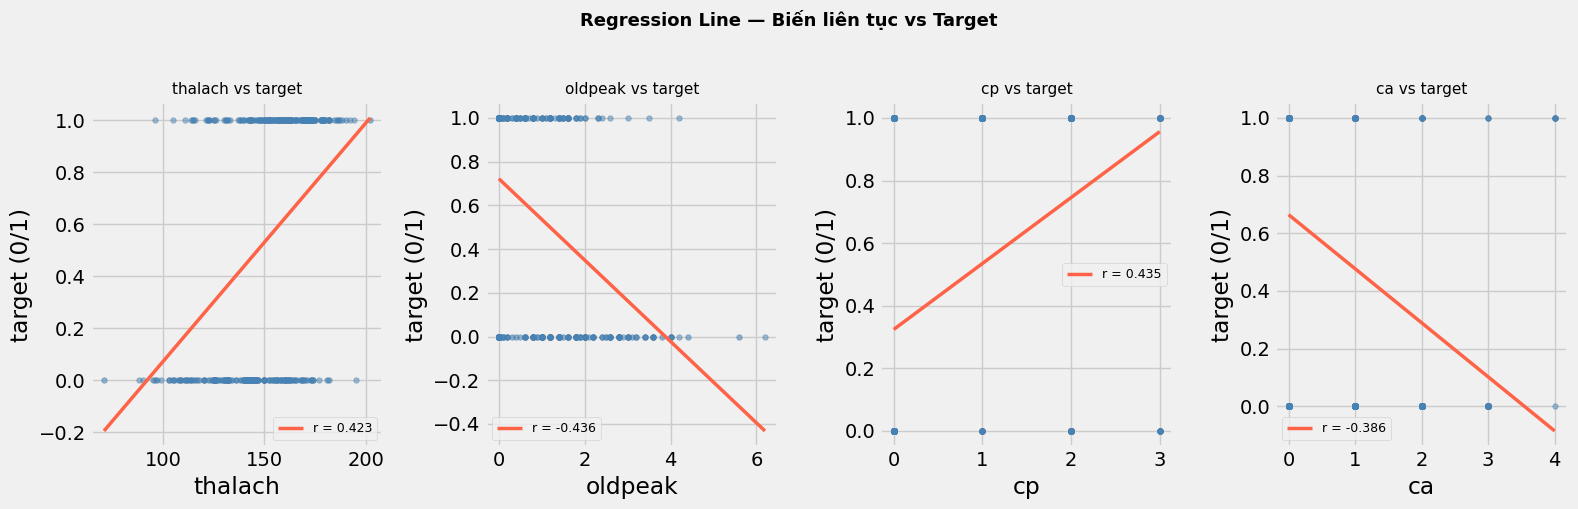

In [ ]:
# Visualize scatter + regression line
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
plot_cols = ['thalach', 'oldpeak', 'cp', 'ca']

for ax, col in zip(axes, plot_cols):
    if col not in reg_results:
        continue
    x = df[col].values
    y = df['target'].values

    ax.scatter(x, y, alpha=0.12, color='steelblue', s=15)

    a, b = reg_results[col]['a'], reg_results[col]['b']
    r    = reg_results[col]['r']
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, a + b * x_line,
            color='tomato', linewidth=2.5,
            label=f'r = {r:.3f}')

    ax.set_xlabel(col)
    ax.set_ylabel('target (0/1)')
    ax.set_title(f'{col} vs target', fontsize=11)
    ax.legend(fontsize=9)

plt.suptitle('Regression Line — Biến liên tục vs Target',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

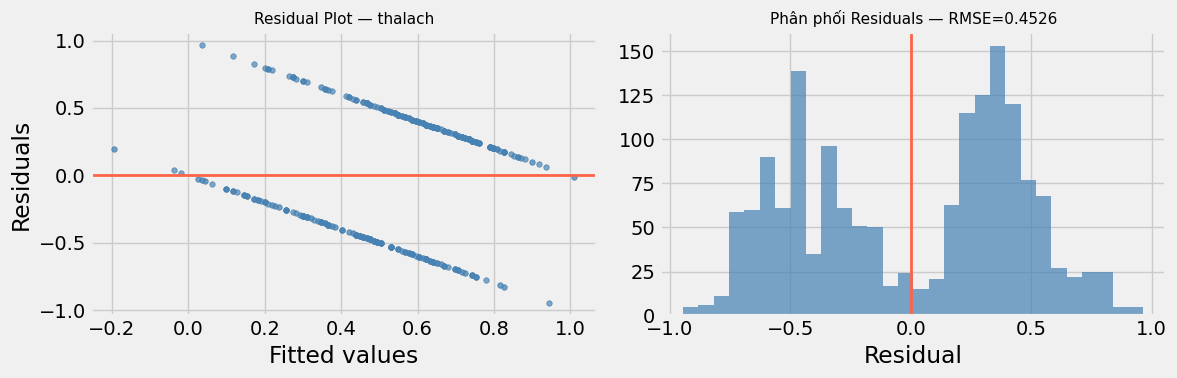

In [ ]:
# Phân tích phần dư — kiểm tra mô hình có phù hợp không

col = 'thalach'
x   = df[col].values
y   = df['target'].values.astype(float)
a, b, r = regression_line(x, y)
y_pred  = a + b * x
residuals = y - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_pred, residuals, alpha=0.2,
                color='steelblue', s=15)
axes[0].axhline(0, color='tomato', linewidth=2)
axes[0].set_xlabel('Fitted values')
axes[0].set_ylabel('Residuals')
axes[0].set_title(f'Residual Plot — {col}', fontsize=11)

axes[1].hist(residuals, bins=30, color='steelblue', alpha=0.7)
axes[1].axvline(0, color='tomato', linewidth=2)
axes[1].set_xlabel('Residual')
axes[1].set_title(f'Phân phối Residuals — RMSE={rmse(y,y_pred):.4f}',
                  fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
# KNN 

def normalize(arr):
    """Scale về [0,1] để so sánh features công bằng — MỞ RỘNG"""
    return (arr - np.min(arr)) / (np.max(arr) - np.min(arr) + 1e-8)

def knn_predict(train_X, train_y, test_point, k=5):
    """
    KNN: tìm k điểm gần nhất trong train, vote majority
    Đúng theo Data 8: dùng khoảng cách Euclidean
    """
    distances = np.sqrt(np.sum((train_X - test_point) ** 2, axis=1))
    k_nearest = train_y[np.argsort(distances)[:k]]
    return int(np.sum(k_nearest) > k / 2)   # majority vote

# Dùng features ít chi phí nhất tìm K 
tier12_features = [f for f in ['sex', 'cp', 'trestbps', 'restecg']
                   if f in df.columns]
print(f"Features Tier1+2: {tier12_features}")

# Chuẩn bị data
X_raw = df[tier12_features].values
y     = df['target'].values

# Normalize
X = np.column_stack([normalize(X_raw[:, i])
                     for i in range(X_raw.shape[1])])

# Train/test split (80/20) 
np.random.seed(42)
n         = len(df)
idx       = np.random.permutation(n)
split     = int(0.8 * n)
train_idx = idx[:split]
test_idx  = idx[split:]

X_train, y_train = X[train_idx], y[train_idx]
X_test,  y_test  = X[test_idx],  y[test_idx]

print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Features Tier1+2: ['sex', 'cp', 'trestbps', 'restecg']
Train: 1304 | Test: 327


In [ ]:
# Chạy KNN với k=5 (giáo trình dùng k-nearest neighbors)
k = 5
y_pred = np.array([
    knn_predict(X_train, y_train, x_point, k=k)
    for x_point in X_test
])

accuracy = np.mean(y_pred == y_test)
print(f"\nKNN (k={k}) Accuracy = {accuracy:.4f}")

# Phân tích lỗi
tp = np.sum((y_pred == 1) & (y_test == 1))
tn = np.sum((y_pred == 0) & (y_test == 0))
fp = np.sum((y_pred == 1) & (y_test == 0))
fn = np.sum((y_pred == 0) & (y_test == 1))

print(f"\nTrue  Positive (bệnh → đúng) : {tp}")
print(f"True  Negative (khoẻ → đúng) : {tn}")
print(f"False Positive (khoẻ → sai)  : {fp}  ← loại sai lầm 1")
print(f"False Negative (bệnh → sai)  : {fn}  ← loại sai lầm 2 (nguy hiểm hơn)")


KNN (k=5) Accuracy = 0.8654

True  Positive (bệnh → đúng) : 140
True  Negative (khoẻ → đúng) : 143
False Positive (khoẻ → sai)  : 15  ← loại sai lầm 1
False Negative (bệnh → sai)  : 29  ← loại sai lầm 2 (nguy hiểm hơn)


In [ ]:
# So sánh k khác nhau — chọn k tối ưu

print("\nSo sánh accuracy theo k:")
print("=" * 35)

k_results = []
for k_val in [1, 3, 5, 7, 11, 15]:
    preds = np.array([
        knn_predict(X_train, y_train, x, k=k_val)
        for x in X_test
    ])
    acc = np.mean(preds == y_test)
    k_results.append({'k': k_val, 'accuracy': acc})
    bar = '█' * int(acc * 30)
    print(f"  k={k_val:>2}: {acc:.4f}  {bar}")

best_k = max(k_results, key=lambda x: x['accuracy'])
print(f"\n→ Best k = {best_k['k']} (accuracy = {best_k['accuracy']:.4f})")


So sánh accuracy theo k:
  k= 1: 0.8593  █████████████████████████
  k= 3: 0.8624  █████████████████████████
  k= 5: 0.8654  █████████████████████████
  k= 7: 0.8257  ████████████████████████
  k=11: 0.8012  ████████████████████████
  k=15: 0.8196  ████████████████████████

→ Best k = 5 (accuracy = 0.8654)


In [ ]:
# Chạy KNN cho 4 tầng 

tier_sets = {
    'Tier 1  ($0)'    : ['sex'],
    'Tier 1+2 ($50)'  : ['sex', 'cp', 'trestbps', 'restecg'],
    'Tier 1+2+3 ($310)': ['sex', 'cp', 'trestbps', 'restecg',
                           'chol', 'thalach', 'exang', 'oldpeak', 'slope'],
    'Full ($1010)'    : ['sex', 'cp', 'trestbps', 'restecg',
                         'chol', 'thalach', 'exang', 'oldpeak', 'slope',
                         'ca', 'thal'],
}

print("=" * 55)
print("KNN (k=5) Accuracy theo Tầng chi phí")
print("(Train/Test split 80/20 — random seed=42)")
print("=" * 55)

final_rows = []
for tier_name, feats in tier_sets.items():
    feats = [f for f in feats if f in df.columns]
    X_raw = df[feats].values
    X_n   = np.column_stack([normalize(X_raw[:, i])
                              for i in range(X_raw.shape[1])])

    X_tr = X_n[train_idx]
    X_te = X_n[test_idx]

    preds = np.array([
        knn_predict(X_tr, y_train, x, k=5)
        for x in X_te
    ])
    acc = np.mean(preds == y_test)
    final_rows.append({'tier': tier_name, 'accuracy': acc,
                       'n_features': len(feats)})
    bar = '█' * int(acc * 30)
    print(f"{tier_name:<22} acc={acc:.4f}  {bar}")

print("\n Kết luận: Feature set nào đạt accuracy tốt nhất với chi phí thấp?")

# Lưu kết quả cuối
pd.DataFrame(final_rows).to_csv('D:\\Case Study\\data\\week4_final.csv', index=False)
print(" Đã lưu week4_final.csv")

KNN (k=5) Accuracy theo Tầng chi phí
(Train/Test split 80/20 — random seed=42)
Tier 1  ($0)           acc=0.6575  ███████████████████
Tier 1+2 ($50)         acc=0.8654  █████████████████████████
Tier 1+2+3 ($310)      acc=0.9694  █████████████████████████████
Full ($1010)           acc=0.9694  █████████████████████████████

 Kết luận: Feature set nào đạt accuracy tốt nhất với chi phí thấp?
 Đã lưu week4_final.csv
